In [5]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import ipywidgets as widgets
from IPython.display import display, clear_output

# === Load CSV ===
df = pd.read_csv("RealLife_2024_7_1_2/First_400_2/ParetoFront.csv")

# === Define objectives ===
objectives = [
    "Driver Violation", "Commute Distance",
    "Transport Machines", "Transport Attachments",
    "Machines", "Workers", "Attachments"
]

# === Create Widgets ===
x_widget = widgets.Dropdown(options=objectives, value="Machines", description="X:")
y_widget = widgets.Dropdown(options=objectives, value="Commute Distance", description="Y:")
output = widgets.Output()

# === Plot Function ===
def update_plot(*args):
    with output:
        clear_output(wait=True)
        x_col, y_col = x_widget.value, y_widget.value
        sub_df = df[[x_col, y_col]].dropna().sort_values(x_col)

        x, y = sub_df[x_col].values, sub_df[y_col].values
        dx, dy = np.diff(x), np.diff(y)
        tradeoff = np.divide(dy, dx, out=np.zeros_like(dy, dtype=float), where=dx != 0)
        avg_tradeoff = np.mean(np.abs(tradeoff[np.isfinite(tradeoff)]))

        plt.figure(figsize=(8, 5))
        plt.scatter(x, y, alpha=0.8)
        plt.xlabel(x_col)
        plt.ylabel(y_col)
        plt.title(f"{y_col} vs. {x_col}")
        plt.grid(True)
        plt.tight_layout()
        plt.show()
        print(f"🔁 Avg. Trade-off: {avg_tradeoff:.2f} Δ{y_col} / Δ{x_col}")

# === Register change once ===
x_widget.observe(update_plot, names="value")
y_widget.observe(update_plot, names="value")

# === Initial plot + display ===
update_plot()
display(widgets.HBox([x_widget, y_widget]), output)

Output()

🔁 Avg. Trade-off: 4.87 ΔAttachments / ΔTransport Attachments


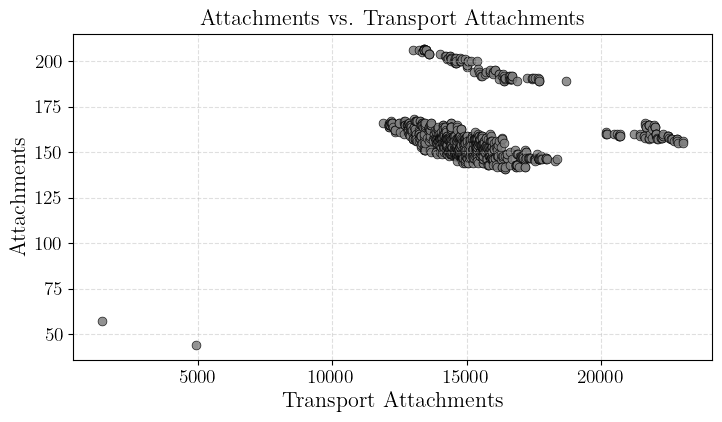

In [7]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from matplotlib import rcParams

# === Stil für wissenschaftliches Plotten ===
rcParams.update({
    "text.usetex": True,
    "font.family": "serif",
    "font.size": 16,
    "axes.labelsize": 16,
    "xtick.labelsize": 14,
    "ytick.labelsize": 14,
})

# === Daten laden ===
df = pd.read_csv("RealLife_2024_7_1_2/First_400_2/ParetoFront.csv")

# === Achsenwahl hier anpassen ===
x_axis = "Transport Attachments"  # Beispiel: "Machines", "Workers", etc.
y_axis = "Attachments"  # Beispiel: "Driver Violation", "Commute Distance", etc.

# === Plotdaten vorbereiten ===
sub_df = df[[x_axis, y_axis]].dropna().sort_values(x_axis)
x = sub_df[x_axis].values
y = sub_df[y_axis].values

# === Plot erstellen ===
plt.figure(figsize=(7.5, 4.5))
plt.scatter(x, y, alpha=0.85, s=40, color="tab:grey", edgecolors="black", linewidth=0.5)

# Achsenbeschriftungen & Stil
plt.xlabel(x_axis)
plt.ylabel(y_axis)
plt.title(f"{y_axis} vs. {x_axis}", fontsize=16)
plt.grid(True, linestyle="--", alpha=0.4)

# === Optional: Trade-off berechnen und drucken ===
dx = np.diff(x)
dy = np.diff(y)
tradeoff = np.divide(dy, dx, out=np.zeros_like(dy, dtype=float), where=dx != 0)
avg_tradeoff = np.mean(np.abs(tradeoff[np.isfinite(tradeoff)]))
print(f"🔁 Avg. Trade-off: {avg_tradeoff:.2f} Δ{y_axis} / Δ{x_axis}")

# === Plot speichern ===
plt.tight_layout()
#plt.savefig("pareto_tradeoff_plot.pdf", bbox_inches="tight")
plt.show()